# 決定木・Random Forest の基礎検証

「LightGBM にすると良くなるらしい…なぜかは知らない」を理解するための土台。
木が**実際に何をしているか**を、Titanic の実データで 1 ステップずつ確認する。

1. 木の最初の 1 分割 (ジニ不純度)
2. 分割を深くする = 空間を区切る
3. 深くしすぎると過学習
4. Random Forest = 違う木の平均
5. ブースティングは「残差」を追う (RF との違い)

In [1]:
import sys
sys.path.insert(0, "../src")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Noto Sans CJK JP"
plt.rcParams["axes.unicode_minus"] = False
from tree import DecisionTree, FEATURES
from random_forest import RandomForest
from catboost import CatBoost

df = pd.read_csv("../data/train.csv")
train, val = df.iloc[:712], df.iloc[712:]
print(f"train {len(train)} 人 / val {len(val)} 人 / 全体の生存率 {df.Survived.mean():.1%}")

train 712 人 / val 179 人 / 全体の生存率 38.4%


## 1. 木の最初の 1 分割 — ジニ不純度

木は「**分割後にデータがどれだけきれいに分かれたか**」で分割を選ぶ。
指標がジニ不純度: 0 = 全部同じラベル (きれい), 0.5 = 完全に混ざってる (汚い)。
各特徴量の全しきい値を試し、**重み付きジニが最小**になる分割を選ぶ。

In [2]:
def gini(s):
    p = np.mean(s)
    return 1 - p**2 - (1 - p)**2

y0 = train.Survived
print(f"ルート (全 {len(y0)} 人) のジニ: {gini(y0):.4f}")

# 各特徴量の「最良しきい値」を全探索して重み付きジニを比較 (tree.py と同じ計算)
X = train[FEATURES].copy()
X["Sex"] = (X.Sex.str.lower() == "female").astype(int)
X = X.fillna(X.median())
print(f"{'特徴量':<8}{'最良しきい値':>12}{'重み付きジニ':>12}")
for col in FEATURES:
    ws = []
    for thr in np.unique(X[col]):
        m = X[col] <= thr
        if m.all() or not m.any():
            continue
        wg = (m.sum() * gini(y0[m]) + (~m).sum() * gini(y0[~m])) / len(y0)
        ws.append((wg, thr))
    wg, thr = min(ws)
    print(f"{col:<8}{thr:>12.2f}{wg:>12.4f}")

t1 = DecisionTree(max_depth=1, min_samples_leaf=5).fit(train)
print("\n学習された深さ 1 の木:")
t1.print_rules(FEATURES)

ルート (全 712 人) のジニ: 0.4760
特徴量           最良しきい値      重み付きジニ
Pclass          2.00      0.4308
Sex             0.00      0.3371


Age             5.00      0.4678
Fare           10.46      0.4358



学習された深さ 1 の木:
├─ Sex <= 0.0? (n=712)
  → 生存 0.19 (n=456)
└─ Sex >  0.0
  → 生存 0.74 (n=256)


## 2. 分割を深くする = 空間を区切る

深さ 3 の木のルールを見る。葉 = 「似た人たちのグループ」で、生存確率と人数を持つ。
Age/Fare 平面で見ると、木は**長方形の領域に空間を区切って**いる。

In [3]:
t3 = DecisionTree(max_depth=3, min_samples_leaf=10).fit(train)
t3.print_rules(FEATURES)

├─ Sex <= 0.0? (n=712)
  ├─ Pclass <= 1.0? (n=456)
    ├─ Age <= 52.0? (n=102)
      → 生存 0.42 (n=81)
    └─ Age >  52.0
      → 生存 0.14 (n=21)
  └─ Pclass >  1.0
    ├─ Age <= 12.0? (n=354)
      → 生存 0.50 (n=22)
    └─ Age >  12.0
      → 生存 0.12 (n=332)
└─ Sex >  0.0
  ├─ Pclass <= 2.0? (n=256)
    ├─ Age <= 2.0? (n=135)
      → 生存 0.50 (n=2)
    └─ Age >  2.0
      → 生存 0.95 (n=133)
  └─ Pclass >  2.0
    ├─ Fare <= 24.1? (n=121)
      → 生存 0.58 (n=103)
    └─ Fare >  24.1
      → 生存 0.11 (n=18)


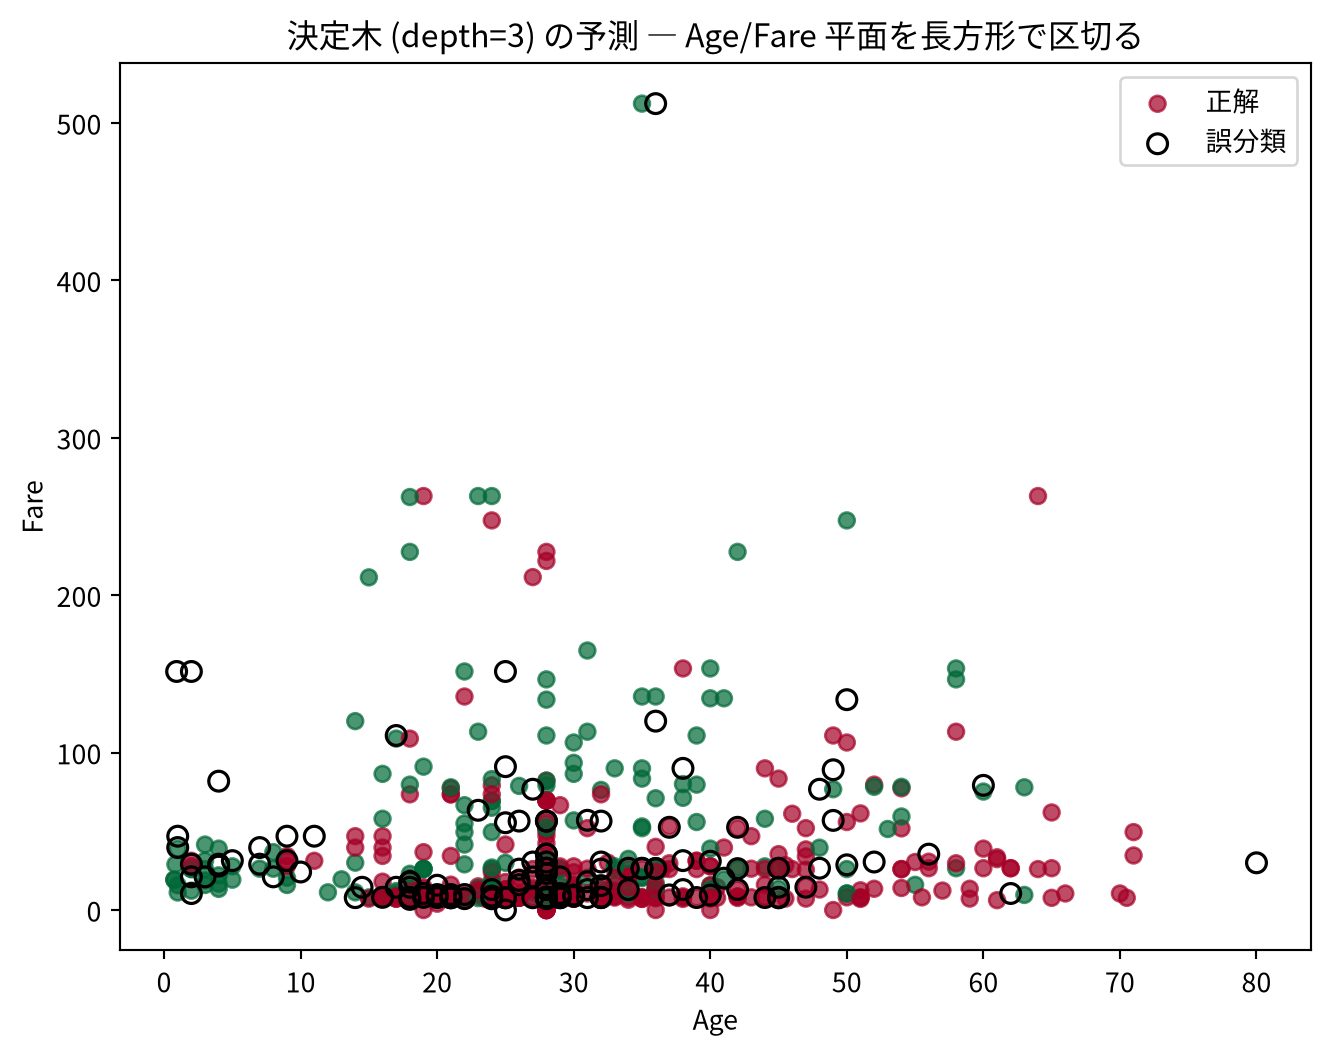

In [4]:
# 深さ 3 の木が Age/Fare 平面をどう区切ったか (○=正解, 枠=誤分類)
Xtr = train[["Age", "Fare"]].copy()
Xtr["Age"] = Xtr.Age.fillna(train.Age.median())
pred = t3.predict(train).to_numpy()
ok = pred == train.Survived.to_numpy()
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(Xtr.Age[ok], Xtr.Fare[ok], c=pred[ok].astype(int), cmap="RdYlGn",
           s=35, alpha=0.7, label="正解")
ax.scatter(Xtr.Age[~ok], Xtr.Fare[~ok], s=55, facecolors="none",
           edgecolors="black", linewidths=1.2, label="誤分類")
ax.set_xlabel("Age"); ax.set_ylabel("Fare"); ax.legend()
ax.set_title("決定木 (depth=3) の予測 — Age/Fare 平面を長方形で区切る")
plt.show()

## 3. 深くしすぎると過学習

深さ = 分割の細かさ = 複雑さ。深くすると train はどんどん上がる (丸暗記)。
でも val は「上がって下がる」。**最適な複雑さは 1 つ**で、それを超えると過学習。

max_depth    train      val
        1 0.783708 0.798883
        2 0.783708 0.798883
        3 0.803371 0.837989
        4 0.821629 0.837989
        6 0.866573 0.854749
        8 0.900281 0.837989
       10 0.917135 0.843575
      712 0.977528 0.793296


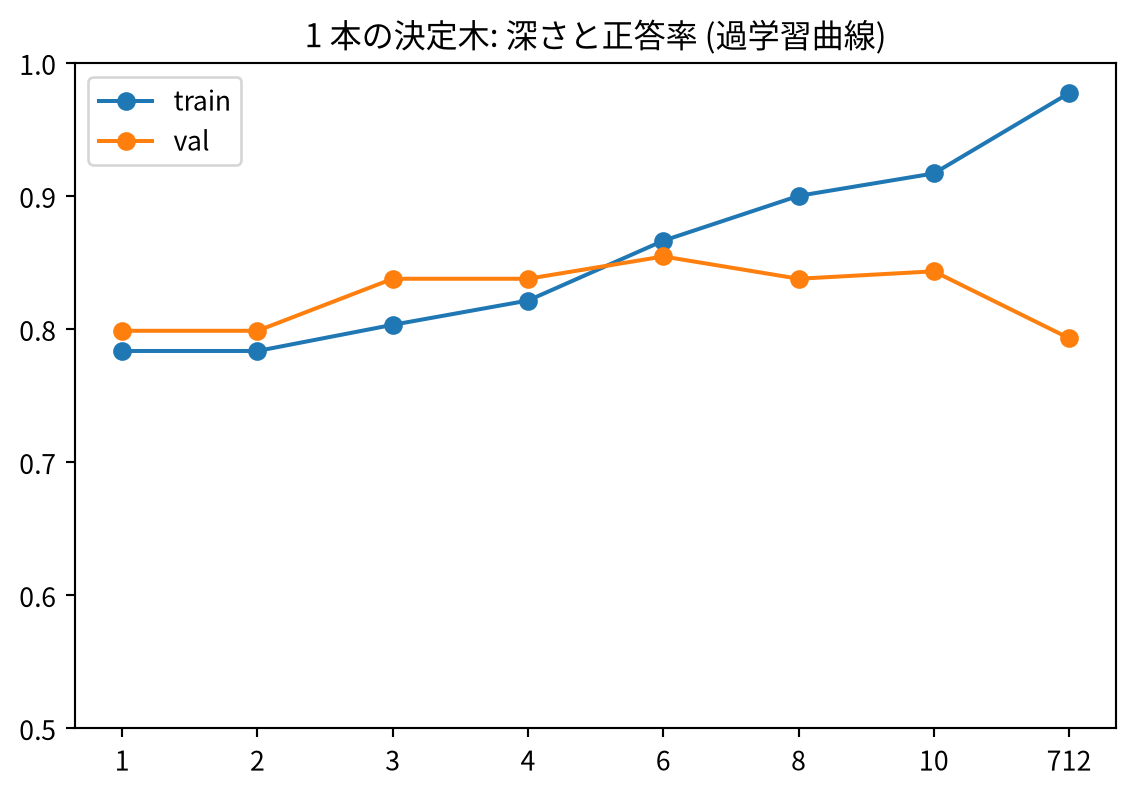

In [5]:
rows = []
for d in [1, 2, 3, 4, 6, 8, 10, 712]:  # 712 ≈ 無制限
    t = DecisionTree(max_depth=d, min_samples_leaf=1).fit(train)
    rows.append((str(d),
                 float((t.predict(train) == train.Survived).mean()),
                 float((t.predict(val) == val.Survived).mean())))
s = pd.DataFrame(rows, columns=["max_depth", "train", "val"])
print(s.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(range(len(s)), s.train, "o-", label="train")
ax.plot(range(len(s)), s.val, "o-", label="val")
ax.set_xticks(range(len(s))); ax.set_xticklabels(s.max_depth)
ax.set_ylim(0.5, 1.0); ax.legend()
ax.set_title("1 本の決定木: 深さと正答率 (過学習曲線)")
plt.show()

## 4. Random Forest = 違う木の平均

RF はブートストラップ標本 (復元抽出した別のデータ) ごとに木を作る。
ルート分割はたいてい同じ (Sex が圧倒的に効く) でも、**それぞれの木は少しずつ違う予測をする**
(val 正答率が 0.81〜0.87 とばらつく = 不安定性)。それを平均すると偶然が打ち消されて安定する。

In [6]:
rng = np.random.default_rng(0)
trees = []
for i in range(5):
    idx = rng.integers(0, len(train), len(train))
    t = DecisionTree(max_depth=3, min_samples_leaf=10).fit(train.iloc[idx])
    trees.append(t)
    va = float((t.predict(val) == val.Survived).mean())
    print(f"  木{i}: val 正答率 {va:.4f}")

votes = np.vstack([t.predict(val).to_numpy() for t in trees])
split = (votes != votes[0]).any(axis=0)
print(f"\n5 本の木が予測を割った val の人数: {split.sum()} / {len(val)}"
      f" (= 木ごとの不安定性。RF は平均で吸収する)")

t = DecisionTree(max_depth=4, min_samples_leaf=10).fit(train)
rf = RandomForest(n_estimators=200, max_depth=4, min_samples_leaf=10, seed=0).fit(train)
print(f"\n単一の木       val: {(t.predict(val) == val.Survived).mean():.4f}")
print(f"RandomForest(200本) val: {(rf.predict(val) == val.Survived).mean():.4f}")

  木0: val 正答率 0.8101
  木1: val 正答率 0.8603
  木2: val 正答率 0.8715
  木3: val 正答率 0.8324
  木4: val 正答率 0.8436

5 本の木が予測を割った val の人数: 25 / 179 (= 木ごとの不安定性。RF は平均で吸収する)



単一の木       val: 0.8380
RandomForest(200本) val: 0.8547


## 5. ブースティングは「残差」を追う (RF との違い)

RF は**平行**: 500 本の木が同じ目標 y を独立に学習し、平均する。
ブースティング (CatBoost/LightGBM) は**逐次**: 1 本目の木の**外し方 (残差)** に
2 本目をフィットし、さらにその残差に 3 本目…と積み重ねる。
iterations を増やすと train は単調に上がる (残差を詰め続ける) が、
**val はある点でピークを打って下がる = 過学習**。

In [7]:
print(f"{'iterations':<6}{'train正答率':>12}{'val正答率':>12}")
rows = []
for it in [1, 5, 20, 100, 200, 400]:
    cb = CatBoost(iterations=it, depth=3, min_samples_leaf=5, seed=0).fit(train)
    tr = float((cb.predict(train) == train.Survived).mean())
    va = float((cb.predict(val) == val.Survived).mean())
    rows.append((it, tr, va))
    print(f"{it:<6}{tr:>12.4f}{va:>12.4f}")
best = max(rows, key=lambda r: r[2])
print(f"\n→ train は単調に上がる (残差を詰める) が、val は iterations={best[0]} でピーク"
      f" ({best[2]:.4f}) → その後は過学習。")
print("   RF (平行平均) と boosting (逐次で残差を詰める) は『複雑さを使う方向』が違う。")

iterations    train正答率      val正答率
1           0.6096      0.6425


5           0.7837      0.8324


20          0.8287      0.8492


100         0.8947      0.8547


200         0.9143      0.8492


400         0.9424      0.8380

→ train は単調に上がる (残差を詰める) が、val は iterations=100 でピーク (0.8547) → その後は過学習。
   RF (平行平均) と boosting (逐次で残差を詰める) は『複雑さを使う方向』が違う。
